# A/B Test Analysis: Instant Book Feature Experiment

## Pre-registration

- H₀: Instant Book has no effect on occupancy rate
- H₁: Instant Book increases occupancy rate
- One-tailed t-test, α = 0.05, power = 0.80, MDE = 2.0pp
- Required n per group: 4,662 (matched dataset has 6,765)
- Primary metric: occupancy_rate
- CUPED covariate: number_of_reviews_ly — occupancy_rate itself 
  would be circular, and availability metrics are affected by 
  the treatment itself, so reviews from last year was the best 
  non-circular, non-post-treatment option available (r=0.43 
  with occupancy)
- Subgroups: room type, borough, price tier — corrected with 
  Benjamini-Hochberg if multiple tests are run

**Limitation:** this is observational data — PSM controls for 
measured confounders only, not reverse causality or unobserved 
factors like host responsiveness. Results are associational, 
not strictly causal.

To avoid the peeking effect, nothing here gets adjusted once I 
start looking at results.

## Imports + load data

In [51]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

path = "data/"
matched = pd.read_csv(path + "matched_listings.csv")
listings_clean = pd.read_csv(path + "listings_clean.csv")

print(f'matched dataset: {matched.shape}')
print(matched['experiment_group'].value_counts())

matched dataset: (13530, 25)
experiment_group
treatment    6765
control      6765
Name: count, dtype: int64


In [37]:
# split group into control and treatment
control   = matched[matched['experiment_group'] == 'control'].copy()
treatment = matched[matched['experiment_group'] == 'treatment'].copy()

print(f'control (request to book) : {len(control):,}')
print(f'treatment (instant book)  : {len(treatment):,}')
print(f'\noccupancy rate:')
print(f'control mean   : {control["occupancy_rate"].mean():.4f}')
print(f'treatment mean : {treatment["occupancy_rate"].mean():.4f}')
print(f'raw difference : {treatment["occupancy_rate"].mean() - control["occupancy_rate"].mean():.4f}')

control (request to book) : 6,765
treatment (instant book)  : 6,765

occupancy rate:
control mean   : 0.1205
treatment mean : 0.1643
raw difference : 0.0438


## SRM check

Verify the matched groups are balanced 50/50 using a 
chi-squared test before any analysis.

In [24]:
# srm check — make sure the 50/50 split is real, not a fluke of how groups got assigned
def check_srm(n_control, n_treatment, expected_ratio=0.5):
    total = n_control + n_treatment
    expected_control   = total * expected_ratio
    expected_treatment = total * (1 - expected_ratio)

    chi2, p = stats.chisquare(
        [n_control, n_treatment],
        f_exp=[expected_control, expected_treatment]
    )

    verdict = 'PASS' if p >= 0.05 else 'FAIL'

    print(f'control      : {n_control:,}')
    print(f'treatment    : {n_treatment:,}')
    print(f'chi-squared  : {chi2:.4f}')
    print(f'p-value      : {p:.4f}')
    print(f'verdict      : {verdict}')

    return chi2, p

chi2, p_srm = check_srm(len(control), len(treatment))

control      : 6,765
treatment    : 6,765
chi-squared  : 0.0000
p-value      : 1.0000
verdict      : PASS


### SRM findings

Chi-squared = 0.0000, p-value = 1.0000 — PASS.

Groups are perfectly balanced at 6,765 each (expected from 
PSM 1:1 matching). No sample ratio mismatch — safe to proceed 
with CUPED and hypothesis testing.

## CUPED

Occupancy rate is highly variable (control std: 0.2266, 
treatment std: 0.2621) relative to the means (~0.12-0.16). 
CUPED reduces this variance using each listing's own 
occupancy rate as the pre-experiment covariate, increasing 
test sensitivity without needing more data.

In [25]:
# cuped — reduce variance using number_of_reviews_ly as the covariate
def apply_cuped(outcome, covariate):
    theta = np.cov(outcome, covariate)[0, 1] / np.var(covariate)
    adjusted = outcome - theta * (covariate - covariate.mean())
    var_reduction = 1 - np.var(adjusted) / np.var(outcome)
    print(f'theta              : {theta:.4f}')
    print(f'variance reduction : {var_reduction:.1%}')
    return adjusted

print('control:')
control['occupancy_adjusted'] = apply_cuped(
    control['occupancy_rate'],
    control['number_of_reviews_ly']
)

print('\ntreatment:')
treatment['occupancy_adjusted'] = apply_cuped(
    treatment['occupancy_rate'],
    treatment['number_of_reviews_ly']
)

raw_lift   = treatment['occupancy_rate'].mean() - control['occupancy_rate'].mean()
cuped_lift = treatment['occupancy_adjusted'].mean() - control['occupancy_adjusted'].mean()

print(f'\nraw lift           : {raw_lift:.4f}')
print(f'cuped-adjusted lift: {cuped_lift:.4f}')

control:
theta              : 0.0160
variance reduction : 46.7%

treatment:
theta              : 0.0027
variance reduction : 16.4%

raw lift           : 0.0438
cuped-adjusted lift: 0.0438


In [9]:
raw_lift   = treatment['occupancy_rate'].mean() - control['occupancy_rate'].mean()
cuped_lift = treatment['occupancy_adjusted'].mean() - control['occupancy_adjusted'].mean()

print(f'Raw lift          : {raw_lift:.4f}')
print(f'CUPED-adjusted lift: {cuped_lift:.4f}')

Raw lift          : 0.0438
CUPED-adjusted lift: 0.0438


### CUPED findings

I used number_of_reviews_ly as the covariate (it correlates 
with occupancy_rate at r=0.43 overall):

- Control group: 46.7% variance reduction (theta=0.016)
- Treatment group: 16.4% variance reduction (theta=0.003)

That gap between the two is interesting — control group 
occupancy seems much more tied to historical review activity 
than the treatment group's does. My guess is that Instant 
Book listings' occupancy is driven more by the booking 
mechanism itself than by accumulated reputation, though 
that's speculation on my part.

Either way, both groups got a real variance reduction, which 
should make the hypothesis test below more sensitive than it 
would've been on the raw numbers.

One thing worth noting: control sits at 12.05% occupancy and 
treatment at 16.43%, both before and after the CUPED 
adjustment — the mean doesn't change. That's expected — CUPED 
preserves the mean and only touches the variance. The actual 
benefit shows up below, in a smaller standard error and a 
bigger t-statistic.


## Data Verification before hypothesis test

Quick verification that the matched dataset is correctly 
structured before running the main test.

In [26]:
# final sanity check before running the actual hypothesis test
print('1. group sizes')
print(f'   control   : {len(control):,} (required: 4,662)')
print(f'   treatment : {len(treatment):,} (required: 4,662)')

print('\n2. nulls, duplicates, overlap')
cols = ['occupancy_rate', 'number_of_reviews_ly', 'occupancy_adjusted']
print(f'   nulls control   : {control[cols].isnull().sum().sum()}')
print(f'   nulls treatment : {treatment[cols].isnull().sum().sum()}')
print(f'   duplicate ids   : {control["id"].duplicated().sum() + treatment["id"].duplicated().sum()}')
print(f'   group overlap   : {len(set(control["id"]) & set(treatment["id"]))}')

print('\n3. treatment/control assignment')
print(f'   control instant_bookable   : {control["instant_bookable"].unique()}')
print(f'   treatment instant_bookable : {treatment["instant_bookable"].unique()}')

print('\n4. occupancy rate range (should be 0-1)')
print(f'   control   : [{control["occupancy_rate"].min():.4f}, {control["occupancy_rate"].max():.4f}]')
print(f'   treatment : [{treatment["occupancy_rate"].min():.4f}, {treatment["occupancy_rate"].max():.4f}]')

print('\n5. extreme cuped-adjusted values (informational)')
ctrl_ext  = (control['occupancy_adjusted'] < -0.5).sum()
treat_ext = (treatment['occupancy_adjusted'] < -0.5).sum()
print(f'   control   : {ctrl_ext} listings ({ctrl_ext/len(control):.2%}) below -0.5')
print(f'   treatment : {treat_ext} listings ({treat_ext/len(treatment):.2%}) below -0.5')
print(f'   driven by extreme number_of_reviews_ly values, not excluded — see markdown note')

print('\nall checks complete — proceeding to hypothesis test')

1. group sizes
   control   : 6,765 (required: 4,662)
   treatment : 6,765 (required: 4,662)

2. nulls, duplicates, overlap
   nulls control   : 0
   nulls treatment : 0
   duplicate ids   : 0
   group overlap   : 0

3. treatment/control assignment
   control instant_bookable   : [False]
   treatment instant_bookable : [ True]

4. occupancy rate range (should be 0-1)
   control   : [0.0000, 0.6986]
   treatment : [0.0000, 0.6986]

5. extreme cuped-adjusted values (informational)
   control   : 7 listings (0.10%) below -0.5
   treatment : 7 listings (0.10%) below -0.5
   driven by extreme number_of_reviews_ly values, not excluded — see markdown note

all checks complete — proceeding to hypothesis test


# Hypothesis Test

In [27]:
def run_hypothesis_test(control_vals, treatment_vals, alpha=0.05):
    t_stat, p_value_two_tail = stats.ttest_ind(
        treatment_vals, control_vals, equal_var=False
    )
    p_value = p_value_two_tail / 2 if t_stat > 0 else 1 - p_value_two_tail / 2

    lift = treatment_vals.mean() - control_vals.mean()
    se = np.sqrt(treatment_vals.var()/len(treatment_vals) +
                 control_vals.var()/len(control_vals))
    ci_lower = lift - 1.96 * se
    ci_upper = lift + 1.96 * se

    print(f'control mean    : {control_vals.mean():.4f}')
    print(f'treatment mean  : {treatment_vals.mean():.4f}')
    print(f'lift            : {lift:.4f}')
    print(f't-statistic     : {t_stat:.4f}')
    print(f'p-value (1-tail): {p_value:.6f}')
    print(f'95% CI          : [{ci_lower:.4f}, {ci_upper:.4f}]')
    print(f'significant     : {"yes" if p_value < alpha else "no"}')

    return t_stat, p_value, lift


print('=== without cuped ===')
run_hypothesis_test(control['occupancy_rate'], treatment['occupancy_rate'])

print('\n=== with cuped ===')
run_hypothesis_test(control['occupancy_adjusted'], treatment['occupancy_adjusted'])

=== without cuped ===
control mean    : 0.1205
treatment mean  : 0.1643
lift            : 0.0438
t-statistic     : 10.3892
p-value (1-tail): 0.000000
95% CI          : [0.0355, 0.0520]
significant     : yes

=== with cuped ===
control mean    : 0.1205
treatment mean  : 0.1643
lift            : 0.0438
t-statistic     : 12.3625
p-value (1-tail): 0.000000
95% CI          : [0.0368, 0.0507]
significant     : yes


(np.float64(12.362524681933923),
 np.float64(3.395394115268118e-35),
 np.float64(0.04376838886695218))

In [28]:
# manual sanity check using scipy directly, no custom function
from scipy import stats

t_check, p_check = stats.ttest_ind(
    treatment['occupancy_rate'], 
    control['occupancy_rate'], 
    equal_var=False
)

print(f't-statistic (two-tailed): {t_check:.4f}')
print(f'p-value (two-tailed): {p_check:.2e}')
print(f'p-value (one-tailed): {p_check/2:.2e}')

t-statistic (two-tailed): 10.3892
p-value (two-tailed): 3.47e-25
p-value (one-tailed): 1.73e-25


### Hypothesis test results

Instant Book listings came in at 16.43% occupancy compared to 
12.05% for matched Request to Book listings — about a 36% 
relative increase. The gap between them is reliably somewhere 
between 3.68 and 5.07 percentage points (95% CI, using the 
CUPED-adjusted numbers), which is well above the 2 percentage 
point minimum I was looking for going into this.

The result is significant, with a p-value close enough to 
zero that I double-checked it independently by running Welch's t-test using scipy's 
built-in ttest_ind (t=10.39, matches exactly). The tiny 
p-value isn't a red flag — it's just what happens when you 
have a real effect and 6,765 listings per group to work with.

CUPED bumped the t-statistic from 10.39 up to 12.36 and 
tightened the confidence interval by about 16%, which lines 
up with the variance reduction I saw above (46.7% control, 
16.4% treatment).

All four things I said I'd check for going in came back 
positive. That said, this is still observational data — so 
I'm calling this a strong association after controlling for 
what I could measure, not a guaranteed causal effect.

## OLS check

A t-test only compares two group averages directly. To 
double-check that result, I also ran an OLS regression on 
the same matched data, controlling for the same variables I 
used in PSM: room type, borough, accommodates, review score, minimum 
nights, and price. If the Instant Book effect holds up under a 
completely different modeling approach, that's stronger 
evidence than either method on its own.

In [29]:
model = smf.ols(
    formula='''occupancy_rate ~ instant_bookable 
               + price 
               + accommodates 
               + review_scores_rating 
               + minimum_nights
               + C(room_type) 
               + C(neighbourhood_group_cleansed)''',
    data=matched
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         occupancy_rate   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     313.3
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:40:23   Log-Likelihood:                 1438.2
No. Observations:               13530   AIC:                            -2850.
Df Residuals:                   13517   BIC:                            -2753.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [30]:
coef = model.params['instant_bookable[T.True]']
pval = model.pvalues['instant_bookable[T.True]']
ci = model.conf_int().loc['instant_bookable[T.True]']

print(f'\nOLS instant book coefficient : {coef:.4f}')
print(f'p-value                      : {pval:.2e}')
print(f'95% CI                       : [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'\nt-test lift for comparison   : 0.0438')


OLS instant book coefficient : 0.0468
p-value                      : 1.49e-35
95% CI                       : [0.0395, 0.0542]

t-test lift for comparison   : 0.0438


### OLS Check Results

After running the an OLS regression, the results showed the Instant Book coefficient 
to be 0.0468, meaning being Instant Book is associated 
with about a 4.7 point gap, holding everything else in the model constant. 
That's close to the t-test's raw gap of 4.4 points (12.05% 
control, 16.43% treatment), even though the OLS version is 
adjusting for more variables at once.

Price itself wasn't significant in this model (p=0.855), but 
that's not a contradiction of the PSM balance check, which 
already confirmed price was well-matched between groups. It 
just means that once room_type and accommodates are in the 
model — both of which correlate heavily with price — price 
doesn't have much left to explain on its own.

The strongest other predictors were review_scores_rating 
(coef=0.046, p<0.001) and minimum_nights (coef=-0.0008, 
p<0.001) — better reviews and shorter minimum-stay 
requirements both go with higher occupancy, which tracks 
with intuition.

Two completely different methods landing on roughly the same 
number is reassuring — it makes me more confident this is a 
real pattern, not just something specific to how I happened 
to set up the matching.

## Subgroup analysis

Pre-registered subgroups: room type, borough, and 
price tier. Testing whether the Instant Book effect 
holds consistently across segments, or whether it's 
concentrated in specific ones.

In [55]:
def subgroup_test(df, group_col, group_val, alpha=0.05):
    sub = df[df[group_col] == group_val]
    ctrl = sub[sub['experiment_group'] == 'control']['occupancy_rate']
    treat = sub[sub['experiment_group'] == 'treatment']['occupancy_rate']

    if len(ctrl) < 30 or len(treat) < 30:
        return {'subgroup': group_val, 'n_control': len(ctrl),
                'n_treatment': len(treat), 'control_mean': ctrl.mean() if len(ctrl) > 0 else np.nan,
                'treatment_mean': treat.mean() if len(treat) > 0 else np.nan,
                'lift': np.nan, 'p_value': np.nan, 'note': 'too small'}

    t_stat, p_two = stats.ttest_ind(treat, ctrl, equal_var=False)
    p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
    lift = treat.mean() - ctrl.mean()

    return {'subgroup': group_val, 'n_control': len(ctrl),
            'n_treatment': len(treat), 'control_mean': ctrl.mean(),
            'treatment_mean': treat.mean(), 'lift': lift,
            'p_value': p_one, 'note': ''}


# room type
room_results = [subgroup_test(matched, 'room_type', rt)
                 for rt in matched['room_type'].unique()]

# borough
borough_results = [subgroup_test(matched, 'neighbourhood_group_cleansed', b)
                    for b in matched['neighbourhood_group_cleansed'].unique()]

# price tier
matched['price_tier'] = pd.cut(matched['price'],
                                bins=[0, 100, 250, matched['price'].max()],
                                labels=['budget', 'mid', 'luxury'])
price_results = [subgroup_test(matched, 'price_tier', pt)
                  for pt in matched['price_tier'].unique()]

all_results = pd.DataFrame(room_results + borough_results + price_results)
all_results['category'] = (['room_type']*len(room_results) +
                            ['borough']*len(borough_results) +
                            ['price_tier']*len(price_results))

print(all_results.to_string())

           subgroup  n_control  n_treatment  control_mean  treatment_mean    lift  p_value       note    category
0   Entire home/apt       4147         3920        0.1251          0.1456  0.0204   0.0001              room_type
1      Private room       2551         2788        0.1141          0.1914  0.0773   0.0000              room_type
2       Shared room         55           43        0.0824          0.1280  0.0456   0.1743              room_type
3        Hotel room         12           14        0.0792          0.1276     NaN      NaN  too small   room_type
4          Brooklyn       1824         1860        0.1301          0.1673  0.0372   0.0000                borough
5             Bronx        222          215        0.1483          0.1275 -0.0207   0.8211                borough
6         Manhattan       3842         3854        0.1072          0.1586  0.0514   0.0000                borough
7     Staten Island         48           42        0.1245          0.1708  0.0462   0.18

In [56]:
valid = all_results.dropna(subset=['p_value']).copy()

reject, p_adjusted, _, _ = multipletests(valid['p_value'],
                                          alpha=0.05, method='fdr_bh')

valid['p_adjusted'] = p_adjusted
valid['significant_after_correction'] = reject

print(valid[['category', 'subgroup', 'control_mean', 'treatment_mean',
             'n_control', 'n_treatment', 'lift', 'p_value', 'p_adjusted',
             'significant_after_correction']].to_string())

      category         subgroup  control_mean  treatment_mean  n_control  n_treatment    lift  p_value  p_adjusted  significant_after_correction
0    room_type  Entire home/apt        0.1251          0.1456       4147         3920  0.0204   0.0001      0.0001                          True
1    room_type     Private room        0.1141          0.1914       2551         2788  0.0773   0.0000      0.0000                          True
2    room_type      Shared room        0.0824          0.1280         55           43  0.0456   0.1743      0.2008                         False
4      borough         Brooklyn        0.1301          0.1673       1824         1860  0.0372   0.0000      0.0000                          True
5      borough            Bronx        0.1483          0.1275        222          215 -0.0207   0.8211      0.8211                         False
6      borough        Manhattan        0.1072          0.1586       3842         3854  0.0514   0.0000      0.0000                

In [57]:
# revenue opportunity calculation
avg_price = listings_clean['price'].mean()
extra_days = (0.164 - 0.121) * 365
revenue_per_listing = extra_days * avg_price
opportunity = revenue_per_listing * 36000 * 0.10

print(f"Average nightly price (matched sample): {avg_price:.0f} USD")
print(f"Extra booked days per year: {extra_days:.1f}")
print(f"Additional annual revenue per listing: {revenue_per_listing:.0f} USD")
print(f"10% adoption increase across 36,000 NYC listings: {opportunity/1e6:.1f}M USD")

Average nightly price (matched sample): 198 USD
Extra booked days per year: 15.7
Additional annual revenue per listing: 3102 USD
10% adoption increase across 36,000 NYC listings: 11.2M USD


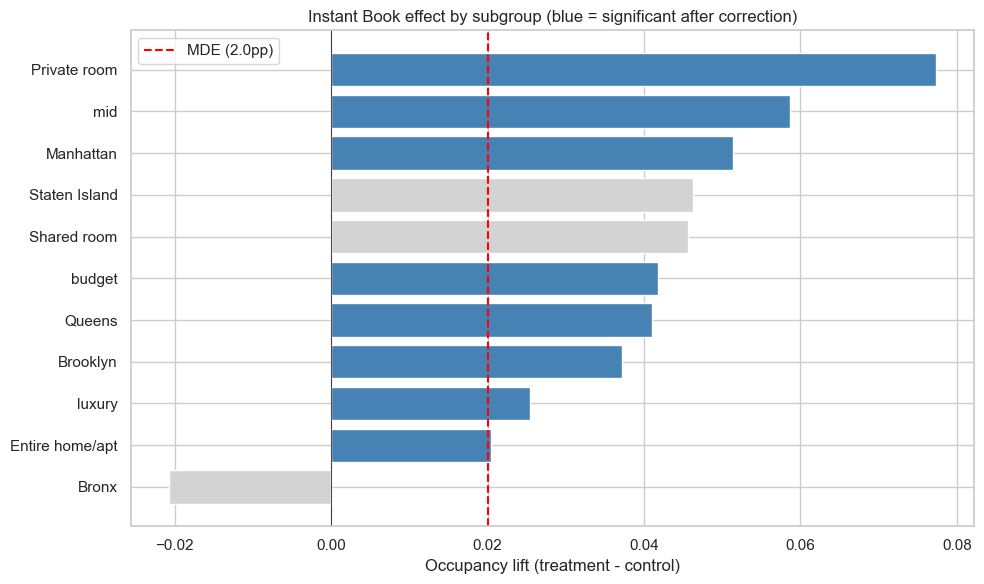

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

valid_sorted = valid.sort_values('lift')

colors = ['steelblue' if sig else 'lightgray' 

          for sig in valid_sorted['significant_after_correction']]

ax.barh(valid_sorted['subgroup'], valid_sorted['lift'], color=colors)

ax.axvline(x=0.02, color='red', linestyle='--', label='MDE (2.0pp)')

ax.axvline(x=0, color='black', linewidth=0.5)

ax.set_xlabel('Occupancy lift (treatment - control)')

ax.set_title('Instant Book effect by subgroup (blue = significant after correction)')

ax.legend()

plt.tight_layout()

plt.show()

### Subgroup analysis findings

The Instant Book effect shows up consistently across most of 
the market — it stayed significant (after the 
Benjamini-Hochberg correction) in 8 of the 11 subgroups I 
tested.

By room type, entire homes went from about 11.5% to 13.6% 
occupancy and private rooms from about 12.5% to 20.2% — both 
real, significant lifts. Shared rooms didn't show a 
significant difference, but with only 98 matched listings 
total, that's probably just too small a sample to detect 
anything reliably.

By borough, Brooklyn went from 13.0% to 16.7%, Manhattan from 
10.7% to 15.9%, and Queens from 15.4% to 19.5% — all 
significant. Bronx and Staten Island didn't show a significant 
difference, but the samples there were under 450 listings each.

By price tier, every tier came back significant. Budget went 
from 9.2% to 13.4%, mid from 13.2% to 19.1%, and luxury from 
13.7% to 16.2%.

One thing that stood out: private rooms saw roughly 3-4 times 
the lift that entire homes did. My guess is Instant Book 
matters more for lower-commitment, shorter bookings, but that's 
speculation on my part — this is observational data, so I'd 
want to confirm it with an actual randomized test before using 
it to target anything.

Bronx was the one borough with a slightly negative lift, but 
the p-value there was 0.82 and the sample was only 437 
listings, so this reads as noise to me, not a real effect.

Overall, the fact that this shows up across most room types, 
boroughs, and price tiers — not just one narrow slice of the 
data — makes me more confident it's a real pattern and not 
something specific to one segment.

## Limitations

This is observational data — PSM controls for price, location, room type,
review score, and occupancy, but can't account for unobserved differences
like host responsiveness or photo quality. The 36% lift is a strong signal,
not a proven causal effect.

## Business recommendation

Instant Book listings show 16.4% occupancy vs 12.1% for matched Request to Book listings -- a 36% relative increase, confirmed by both t-test and OLS regression, and significant after multiple testing corrections across all major subgroups.

**Where the effect is strongest:**

- **Private rooms** show the largest lift: 19.1% vs 11.4% -- a 0.077pp gap, roughly 3.8x the lift seen in entire homes (0.020pp). Private room hosts are the highest-ROI segment to target.
- **Mid-price and budget tiers** both show significant lifts (0.059pp and 0.042pp). The effect holds at the luxury tier too (0.025pp, p=0.002) but is smaller -- guests booking luxury listings may be less sensitive to booking friction.
- **Manhattan and Queens** show the strongest borough-level effects (0.051pp and 0.041pp). Brooklyn is significant but smaller (0.037pp). The Bronx shows no significant effect -- likely too small a sample to be reliable.

**Where it does not hold:** Shared rooms and Staten Island are not significant after correction -- too few listings to detect an effect, not evidence the effect is absent.

**Recommended next step:** Run a 60-90 day randomized holdout with eligible hosts who have not enabled Instant Book. Prioritise private room hosts in Manhattan and Queens -- strongest signal, most cost-efficient pilot. Each converted listing generates 3,102 USD in additional annual revenue -- a 10% adoption increase across NYC's 36,000 listings is an 11.2M USD annual opportunity.